# Differential expression analysis


You have run the nf-core/rnaseq pipeline and checked the first quality control metrics of your fastq files. This was, however, only the primary analysis and we want to take it further.

Due to the computational demand of the pipeline, you only ran the pipeline on two of the 16 samples in the study yesterday. We provide you an essential output of nf-core/rnaseq pipeline in the `data` folder: It contains the combined epression matrix as produced by Salmon, which provides transcript levels for each gene (rows) and each sample (columns).


We would now like to understand exactly the difference between the expression in our groups of mice. 
Which pipeline would you use for this?

> I would use nf-core/differentialabundance, since this explicitely supports data produced by the nf-core/rnaseq workflow and compares groups of observations generating differential statistics, like we want.

Have a close look at the pipeline's "Usage" page on the [nf-core docs](nf-co.re). You will need to create a samplesheet (based on the column names in the provided matrix).

In [ ]:
import pandas as pd

sample_names = pd.read_csv("./data/salmon.merged.gene_counts.tsv", sep="\t")

sample_columns = sample_names.columns.drop(["gene_id", "gene_name"])

samplesheet = pd.DataFrame({
    "sample": sample_columns,
    "Condition": sample_columns.str.replace(r"_\d+$", "", regex=True),
})

samplesheet.to_csv("./data/samplesheet.csv", index=False)
# This saves the samplesheet 

Please paste here the command you used. You may need to inspect the provided expression matrix more closely and create additional files, like a samplesheet (based on the column names) or a contrast file (there happens to also be one in `data/` that you can use).

In [ ]:
nextflow run nf-core/differentialabundance \
-profile docker \
--study_name "oxycodone_withdrawel_in_mice" \
--study_type "rnaseq" \
--input ./data/samplesheet.csv \
--contrasts ./data/contrasts.csv \
--matrix ./data/salmon.merged.gene_counts.tsv \
--genome GRCm38 \
--outdir diffanalysis_results

Explain all the parameters you set and why you set them in this way. If you used or created additional files as input, explain what they are used for.

```bash
nextflow run nf-core/differentialabundance \
-profile docker \
--study_name "oxycodone_withdrawel_in_mice" \       # Necessary identifier
--study_type "rnaseq" \                             # type of input data, rnaseq pipeline ran beforehand
--input ./data/samplesheet.csv \                    # Samplesheet connecting samples to conditions
--contrasts ./data/contrasts.csv \                  # specifies which comparisons should be run on the conditions
--matrix ./data/salmon.merged.gene_counts.tsv \     # gene counts for different samples generated by SALMON in rnaseq pipeline
--genome GRCm38 \                                   # reference genome necessary for normalization of counts by gene length
--outdir diffanalysis_results                       # folder for outputs
```


What were the outputs of the pipeline?

The tool builds the following folder structure (only most important folders discussed):
1. pipeline_info: info about run&completion of subtools & respective computational demand
2. plots: Containing different plots showing the findings of the analysis, such as volcano plots to show diff. exp. genes; pca analysis to see which samples are similar to each other, as well as some hierarchical clusterings (dendrograms)
3. report: This folder contains an html report summarizing the most important plots&findings
4. tables: actual differential expression data, so which genes are up/downregulated how much in which comparison

Would you exclude any samples? If yes, which and why?

>I would exclude SNI_Sel_2 and SNI_Sal_4, because they are far away from all other samples in the PCA plot (as well as in the dendrogram showing a clustering of all samples). This indicates their gene expression looks completely different to all other samples, as well as the other SNI_Sel samples, which means that those are probably erroneous. I would exclude them, since they would shift our results.

![sample_pca](./images/outlier_plot.png)
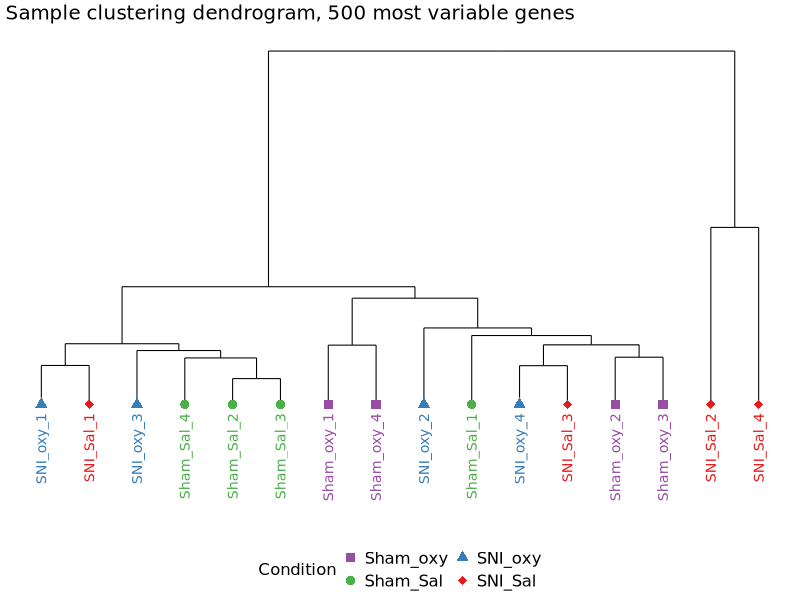

How many genes were differentially expressed in each contrast? Does this confirm what the paper mentions?

> For this we created a new contrasts.csv file containing the comparisons done by the paper:

```csv
id,variable,reference,target
condition_test,Condition,SNI_oxy,Sham_Sal
condition_control_treated_test,Condition,Sham_oxy,Sham_Sal
condition_control,Condition,SNI-Sal,Sham_Sal
```

> Then i rerun the pipeline with the new comparisons 

```bash
nextflow run nf-core/differentialabundance \
-profile docker \
--study_name "oxycodone_withdrawel_in_mice" \
--study_type "rnaseq" \
--input ./data/samplesheet.csv \
--contrasts ./contrasts.csv \
--matrix ./data/salmon.merged.gene_counts.tsv \
--genome GRCm38 \
--outdir diffanalysis_results_2
```

1. Contrast SNI_oxy vs Sham_Sal: 1 upregulated
2. Contrast Sham_oxy vs Sham_Sal: 7 upreglated
3. Contrast SNI-Sal vs Sham_Sal: 73 upregulated, 1 downregulated. 

**This is in major difference to the paper, since in the paper each of the contrast contains hundreds of diff.exp. genes per region(!) (See Fig. 3) while our comparison only contains <<100 over all.**

The paper mentions differentially expressed genes in three brain regions : the NAc, mPFC and VTA. Briefly explain what these 3 regions are.

- NAc: Nucleus accumbens: central point of reward and motivation control
- mPFC: Medial prefrontal cortex: involved in controling emotions and decision-making 
- VTA: ventrale tegmentale Areal: known to regulate/controll reward, motivation and addiction, produces dopamin

Is there anyway from the paper and the material and methods for us to know which genes are included in these regions?

> No. I read the paper and didn't find a clue on how to do this, unfortunately. I also checked supplementary/data, but no. This is really bad, especially when reproducability is important, as here, where upregulation counts differ majorly.

Once you have your list of differentially expressed genes, do you think just communicating those to the biologists would be sufficient? What does the publication state?

> No, thats not enough. The publication's objective is to characterize changes associated with oxycodone withdrawal in the presence or absence of neuropathic pain, across the brain's reward circuitry. Its analysis also considers biological pathways and upstream regulators, including HDAC1 which aren't contained in the deg list alone.

Please reproduce the Venn Diagram from Figure 3, not taking into account the brain regions but just the contrasts mentionned.

In [ ]:
import matplotlib.pyplot as plt
from matplotlib_venn import venn3
import pandas as pd

genes_1 = set(pd.read_csv("./diffanalysis_results_2/tables/differential/contrasts/test1_oxycodone_withdrawel_in_mice.deseq2.results_filtered.tsv", index_col=0).index)
genes_2 = set(pd.read_csv("./diffanalysis_results_2/tables/differential/contrasts/test2_oxycodone_withdrawel_in_mice.deseq2.results_filtered.tsv", index_col=0).index)
genes_3 = set(pd.read_csv("./diffanalysis_results_2/tables/differential/contrasts/test3_oxycodone_withdrawel_in_mice.deseq2.results_filtered.tsv", index_col=0).index)

venn3(
    [group_test_1, group_test_2, group_test_3],
    set_labels=(
        "SNI-oxy vs. Sham-Sal",
        "Sham-oxy vs. Sham-Sal",
        "SNI-Sal vs. Sham-Sal",
    ),
)
plt.title("Vendiagram over contrast")
plt.show()

>We got this Venn as output:

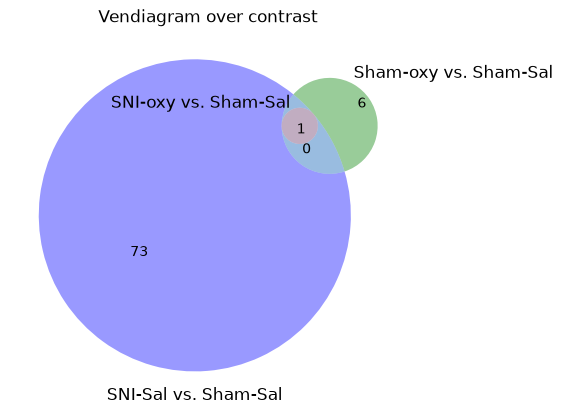